In [1]:
# Cell 1：加载数据 + 删除Li
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_excel('df_cleaned.xlsx')

# 删除Li（全为0，无信息量）
df = df.drop(columns=['Li'])

features = ['Si','Fe','Cu','Mn','Mg','Cr','Zn','V','Ti','Zr',
            'Ni','Be','Sc','Tsol','Tage','tage']
targets  = ['YS', 'UTS', 'El']

print(f"Data shape: {df.shape}")
print(f"Features: {len(features)}, Targets: {len(targets)}")
print(df[targets].describe().round(2))

Data shape: (320, 22)
Features: 16, Targets: 3
           YS     UTS      El
count  320.00  320.00  320.00
mean   417.62  480.66   13.03
std    115.94  105.88    6.16
min    125.00  186.00    1.17
25%    327.00  410.98    9.01
50%    417.45  487.50   13.00
75%    519.52  571.50   16.58
max    611.00  679.00   41.60


In [3]:
# Cell 2：定义三种划分方法
# ── 方法1：纯随机划分 ─────────────────────────────────────────
def split_random(df, test_size=0.2, seed=42):
    dev, test = train_test_split(df, test_size=test_size, random_state=seed)
    return dev.reset_index(drop=True), test.reset_index(drop=True)

# ── 方法2：分层随机划分（按YS/UTS/El综合得分分层）────────────
def split_stratified(df, test_size=0.2, seed=42):
    df = df.copy()

    # 三个目标分别计算百分位排名，取均值作为综合得分
    for tgt in targets:
        df[f'_rank_{tgt}'] = df[tgt].rank(pct=True)

    df['_composite'] = df[[f'_rank_{tgt}' for tgt in targets]].mean(axis=1)

    # 按综合得分分4档做分层
    df['_bin'] = pd.qcut(df['_composite'], q=4, labels=False, duplicates='drop')

    dev, test = train_test_split(df, test_size=test_size,
                                 stratify=df['_bin'], random_state=seed)

    drop_cols = ['_composite', '_bin'] + [f'_rank_{tgt}' for tgt in targets]
    dev  = dev.drop(columns=drop_cols).reset_index(drop=True)
    test = test.drop(columns=drop_cols).reset_index(drop=True)
    return dev, test

# ── 方法3：SPXY划分（特征+目标空间均匀覆盖）─────────────────
def split_spxy(df, test_size=0.2):
    n_test = int(len(df) * test_size)
    X = df[features].values.astype(float)
    y = df[targets].values.astype(float)

    Xs = StandardScaler().fit_transform(X)
    ys = StandardScaler().fit_transform(y)
    Z  = np.hstack([Xs, ys])

    n = len(Z)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = np.linalg.norm(Z[i] - Z[j])
            D[i, j] = D[j, i] = d

    selected  = []
    remaining = list(range(n))

    mean_vec = Z.mean(axis=0)
    first = np.argmax([np.linalg.norm(Z[i] - mean_vec) for i in remaining])
    selected.append(remaining.pop(first))

    while len(selected) < n_test:
        min_dists = [min(D[i, s] for s in selected) for i in remaining]
        next_idx  = remaining[np.argmax(min_dists)]
        selected.append(next_idx)
        remaining.remove(next_idx)

    test = df.iloc[selected].reset_index(drop=True)
    dev  = df.iloc[remaining].reset_index(drop=True)
    return dev, test

print("Splitting methods defined.")

Splitting methods defined.


In [4]:
# Cell 3：执行三种划分
dev_rand,  test_rand  = split_random(df)
dev_strat, test_strat = split_stratified(df)
dev_spxy,  test_spxy  = split_spxy(df)

splits = {
    'Random':     (dev_rand,  test_rand),
    'Stratified': (dev_strat, test_strat),
    'SPXY':       (dev_spxy,  test_spxy),
}

for name, (dev, test) in splits.items():
    print(f"{name}: dev={len(dev)}, test={len(test)}")

Random: dev=256, test=64
Stratified: dev=256, test=64
SPXY: dev=256, test=64


In [5]:
# Cell 4：分布一致性评估函数
def evaluate_split(dev, test, method_name):
    print(f"\n{'='*60}")
    print(f"Method: {method_name}")
    print(f"{'='*60}")

    # ── 目标变量统计对比 ──────────────────────────────────────
    print(f"\n{'Target':<6} {'Set':<8} {'Mean':>8} {'Std':>8} "
          f"{'Q25':>8} {'Q50':>8} {'Q75':>8} {'Low%':>8} {'High%':>8}")
    print("-" * 70)

    for tgt in targets:
        full_q25 = df[tgt].quantile(0.25)
        full_q75 = df[tgt].quantile(0.75)

        for label, subset in [('Full', df), ('Dev', dev), ('Test', test)]:
            d    = subset[tgt]
            low  = (d <= full_q25).mean() * 100
            high = (d >= full_q75).mean() * 100
            print(f"{tgt:<6} {label:<8} {d.mean():>8.2f} {d.std():>8.2f} "
                  f"{d.quantile(0.25):>8.2f} {d.median():>8.2f} "
                  f"{d.quantile(0.75):>8.2f} {low:>7.1f}% {high:>7.1f}%")
        print()

    # ── KS 检验 ───────────────────────────────────────────────
    print(f"KS Test (dev vs test, p>0.05 means similar distribution):")
    print(f"{'Variable':<10} {'KS stat':>10} {'p-value':>10} {'OK?':>8}")
    print("-" * 42)

    ks_results = {}
    for col in targets + features[:8]:  # 检查目标+前8个特征
        ks, p = stats.ks_2samp(dev[col], test[col])
        ok = 'OK' if p > 0.05 else 'DIFF'
        ks_results[col] = (ks, p)
        print(f"{col:<10} {ks:>10.4f} {p:>10.4f} {ok:>8}")

    return ks_results

In [6]:
# Cell 5：运行评估
ks_all = {}
for name, (dev, test) in splits.items():
    ks_all[name] = evaluate_split(dev, test, name)


Method: Random

Target Set          Mean      Std      Q25      Q50      Q75     Low%    High%
----------------------------------------------------------------------
YS     Full       417.62   115.94   327.00   417.45   519.52    25.3%    25.0%
YS     Dev        415.49   114.24   324.25   416.45   519.52    26.2%    25.0%
YS     Test       426.16   123.11   348.75   426.50   520.02    21.9%    25.0%

UTS    Full       480.66   105.88   410.98   487.50   571.50    25.0%    25.3%
UTS    Dev        479.82   103.50   410.52   486.00   569.12    25.8%    24.6%
UTS    Test       484.00   115.75   418.50   503.00   573.00    21.9%    28.1%

El     Full        13.03     6.16     9.01    13.00    16.58    25.0%    25.0%
El     Dev         12.90     6.25     9.00    13.00    16.77    25.8%    25.8%
El     Test        13.57     5.79    10.60    13.85    15.75    21.9%    21.9%

KS Test (dev vs test, p>0.05 means similar distribution):
Variable      KS stat    p-value      OK?
-------------------

C:\Users\PS\AppData\Local\Temp\ipykernel_45412\129483543.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True)
C:\Users\PS\AppData\Local\Temp\ipykernel_45412\129483543.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True)
C:\Users\PS\AppData\Local\Temp\ipykernel_45412\129483543.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True)


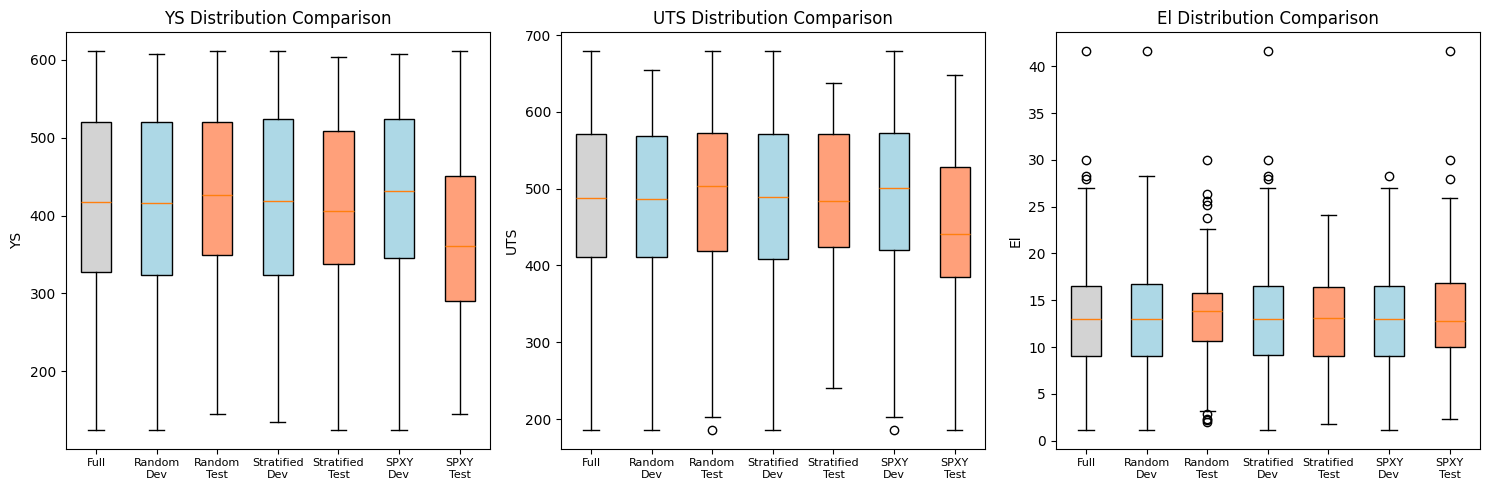

In [7]:
# Cell 6：目标变量箱线图对比
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, tgt in enumerate(targets):
    data_to_plot = []
    labels = []

    for name, (dev, test) in splits.items():
        data_to_plot.append(dev[tgt].values)
        data_to_plot.append(test[tgt].values)
        labels.append(f'{name}\nDev')
        labels.append(f'{name}\nTest')

    # 加入全量参考
    data_to_plot.insert(0, df[tgt].values)
    labels.insert(0, 'Full')

    bp = axes[i].boxplot(data_to_plot, labels=labels, patch_artist=True)

    # 颜色：全量灰，Dev蓝，Test橙
    colors = ['lightgray'] + ['lightblue','lightsalmon'] * 3
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    axes[i].set_title(f'{tgt} Distribution Comparison')
    axes[i].set_ylabel(tgt)
    axes[i].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('split_comparison_boxplot.png', dpi=150)
plt.show()

In [8]:
# Cell 7：KS统计量汇总表
summary_rows = []
for name, ks_dict in ks_all.items():
    n_diff = sum(1 for ks, p in ks_dict.values() if p <= 0.05)
    mean_ks = np.mean([ks for ks, p in ks_dict.values()])
    # 三个目标的平均KS
    target_ks = np.mean([ks_dict[t][0] for t in targets if t in ks_dict])
    summary_rows.append({
        'Method':        name,
        'Mean KS':       round(mean_ks, 4),
        'Target KS':     round(target_ks, 4),
        'N_diff(p<0.05)': n_diff,
        'Dev size':      len(splits[name][0]),
        'Test size':     len(splits[name][1]),
    })

summary = pd.DataFrame(summary_rows)
print("\nSplit Method Summary:")
print(summary.to_string(index=False))
print("\nDecision: lower KS = more similar distributions = better split")
print("Recommended:", summary.loc[summary['Target KS'].idxmin(), 'Method'])


Split Method Summary:
    Method  Mean KS  Target KS  N_diff(p<0.05)  Dev size  Test size
    Random   0.1016     0.1094               0       256         64
Stratified   0.1126     0.1146               1       256         64
      SPXY   0.1673     0.1862               4       256         64

Decision: lower KS = more similar distributions = better split
Recommended: Random


In [9]:
# Cell 8 直接保存 Random 划分结果
dev_final, test_final = splits['Random']

dev_final.to_excel('df_dev.xlsx',   index=False)
test_final.to_excel('df_test.xlsx', index=False)

print(f"Saved: df_dev.xlsx ({len(dev_final)} rows), "
      f"df_test.xlsx ({len(test_final)} rows)")
print(f"\nTarget distribution check:")
for tgt in targets:
    print(f"  {tgt}: Full={df[tgt].mean():.1f}, "
          f"Dev={dev_final[tgt].mean():.1f}, "
          f"Test={test_final[tgt].mean():.1f}")

Saved: df_dev.xlsx (256 rows), df_test.xlsx (64 rows)

Target distribution check:
  YS: Full=417.6, Dev=415.5, Test=426.2
  UTS: Full=480.7, Dev=479.8, Test=484.0
  El: Full=13.0, Dev=12.9, Test=13.6


在完成数据清洗与插补后，对320个样本进行训练集与测试集的划分。为评估不同划分策略的合理性，比较了三种方案：纯随机划分、基于目标变量综合得分的分层随机划分以及SPXY空间划分。其中，SPXY方法基于Kennard-Stone算法，在标准化后的特征与目标联合空间中最大化样本间距，旨在使测试集覆盖整个数据空间的边缘区域。
通过Kolmogorov-Smirnov检验对三种方案的开发集与测试集分布一致性进行定量评估。结果表明，纯随机划分的目标变量平均KS统计量最低（0.109），且三个目标变量的KS检验p值均大于0.05，分布无显著差异。分层划分的Cu含量分布出现显著差异（p=0.009），SPXY划分则在YS、UTS、Fe、Cr等4个变量上出现显著差异，且测试集的低强度样本比例（37.5%）明显高于全量数据（25.0%），说明测试集偏向极端样本，不能代表整体分布。因此，最终采用纯随机划分方案，以固定随机种子（seed=42）按80/20比例将数据划分为开发集（256个样本）和测试集（64个样本）。测试集的YS、UTS和El均值分别为426.2 MPa、484.0 MPa和13.6%，与全量数据（417.6 MPa、480.7 MPa、13.0%）偏差均在5%以内，验证了划分结果的代表性。测试集自此封存，仅用于最终模型评估。